# Assignment 3 - Creating Visualization  

# Visualization 1: Annual Trend of Dogs vs Cats

In [7]:
import pandas as pd
import plotly.express as px
import os

# Step 1: Load the CSV (make sure the file is in the same folder as this notebook)
df = pd.read_csv("Licensed_Dogs_and_Cats.csv")

# Step 2: Inspect data
print("First 5 rows of the dataset:")
print(df.head())

print("\nColumns in the dataset:")
print(df.columns)

# Step 3: Clean the data
# Strip spaces and make consistent case
df['ANIMAL_TYPE'] = df['ANIMAL_TYPE'].str.strip().str.title()  # e.g., 'dog' -> 'Dog'
df['PRIMARY_BREED'] = df['PRIMARY_BREED'].str.strip()

print("\nUnique animal types after cleaning:")
print(df['ANIMAL_TYPE'].unique())

# Step 4: Aggregate annual counts by animal type
annual_counts = df.groupby(['Year', 'ANIMAL_TYPE']).size().reset_index(name='Count')

# Convert Year to int
annual_counts['Year'] = annual_counts['Year'].astype(int)

# Step 5: Create line plot
fig = px.line(
    annual_counts,
    x='Year',
    y='Count',
    color='ANIMAL_TYPE',
    markers=True,
    title="Annual Trend of Licensed Dogs vs Cats in Toronto"
)

#  x-axis show only integer ticks
fig.update_xaxes(dtick=1)

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Number of Licenses"
)

# Step 6: Save figure directly in current working folder
fig.write_image("visualization 1.png")  # saved directly in 02_activities/assignments

# Step 7: Show the figure
fig.show()


First 5 rows of the dataset:
   _id  Year  FSA ANIMAL_TYPE  PRIMARY_BREED
0    1  2023  M3A         DOG  CAVALIER SPAN
1    2  2023  M1K         CAT    DOMESTIC MH
2    3  2023  M4C         CAT    DOMESTIC SH
3    4  2025  M4B         CAT    DOMESTIC SH
4    5  2023  M1V         CAT    DOMESTIC SH

Columns in the dataset:
Index(['_id', 'Year', 'FSA', 'ANIMAL_TYPE', 'PRIMARY_BREED'], dtype='object')

Unique animal types after cleaning:
['Dog' 'Cat']


# Visualization 2: Top 10 Dog Breeds

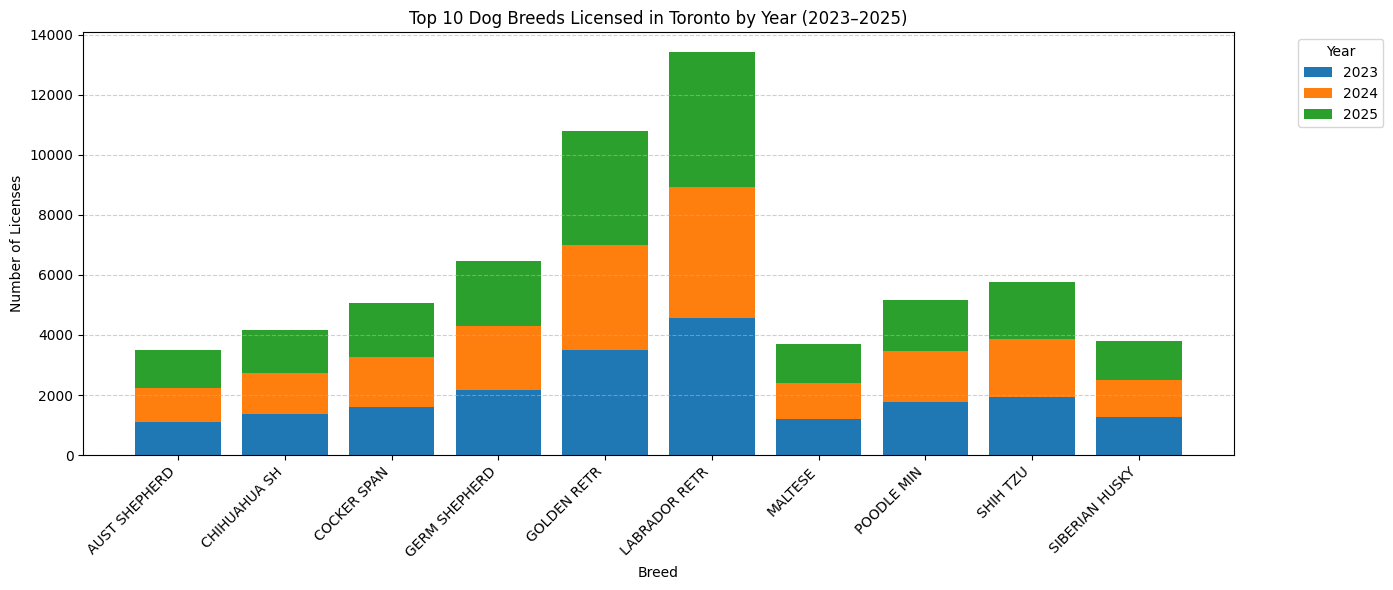

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter dogs only
dog_df = df[df['ANIMAL_TYPE'].astype(str).str.upper() == 'DOG'].copy()

# Ensure Year is numeric and filter range
dog_df['Year'] = pd.to_numeric(dog_df['Year'], errors='coerce')
dog_df = dog_df[dog_df['Year'].between(2023, 2025)]

# Get top 10 breeds overall
top_10_breeds = (
    dog_df['PRIMARY_BREED']
    .value_counts()
    .head(10)
    .index
)

dog_df = dog_df[dog_df['PRIMARY_BREED'].isin(top_10_breeds)]

# Pivot table: rows=breed, columns=year
dog_pivot = (
    dog_df
    .groupby(['PRIMARY_BREED', 'Year'])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)

# ---- PLOT ----
ffig, ax = plt.subplots(figsize=(14, 6))

breeds = dog_pivot.index.tolist()
years = dog_pivot.columns.tolist()
bottom = [0] * len(breeds)

colors = plt.get_cmap('tab10').colors

for i, year in enumerate(years):
    values = dog_pivot[year].values
    ax.bar(
        breeds,
        values,
        bottom=bottom,
        label=str(year),
        color=colors[i % len(colors)]
    )
    bottom = [b + v for b, v in zip(bottom, values)]

# Labels & title
ax.set_title("Top 10 Dog Breeds Licensed in Toronto by Year (2023–2025)")
ax.set_xlabel("Breed")
ax.set_ylabel("Number of Licenses")

# Rotate x-axis labels for readability
ax.set_xticks(range(len(breeds)))
ax.set_xticklabels(breeds, rotation=45, ha='right')

# Grid + legend
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("visualization 2.png")
plt.show()